# PHÂN TÍCH VÀ TRỰC QUAN HÓA BỘ DỮ LIỆU CHUẨN (GROUND TRUTH EDA)
**Môn học:** Xử lý ngôn ngữ tự nhiên (NLP)  
**Báo cáo viên:** [Tên Học Viên]  
**Mục tiêu:** Phân tích đặc trưng thống kê và cấu trúc dữ liệu của bộ benchmark 80 câu hỏi (`test_queries.jsonl`) được gán nhãn bằng quy trình SOTA Retrieval-Assisted Annotation.

---
## 1. PHƯƠNG PHÁP LUẬN GÁN NHÃN ĐỘC LẬP (SOTA RETRIEVAL PIPELINE)

Để triệt tiêu hoàn toàn **Thiên lệch tuần hoàn (Circular Bias)** khi đánh giá hệ thống RAG, bộ Ground Truth được gán nhãn bằng một hệ thống tìm kiếm độc lập quy mô lớn có tính học thuật cao:

### 1.1 Khử nhiễu ngữ nghĩa bằng Mô hình GTE-Qwen2-1.5B-instruct
Mô hình nhúng dense có kích thước **1.5 tỷ tham số** (so với 100M-300M của các mô hình RAG thông thường). 
* **Kiến trúc:** Decoder-only transformer hỗ trợ cơ chế Attention hai chiều (Bidirectional Attention), tối ưu hóa việc học biểu diễn ngữ nghĩa của các câu hỏi dài và phức tạp.
* **Chứng minh hiệu quả:** Đứng top đầu bảng xếp hạng **MTEB (Massive Text Embedding Benchmark)** cho tác vụ tìm tin (Retrieval).

### 1.2 Giảm suy hao số liệu bằng ColBERTv2 (Late Interaction - Tương tác muộn)
Khác với việc nén toàn bộ đoạn văn thành một vector duy nhất (Bi-Encoder), ColBERTv2 giữ nguyên vector biểu diễn của từng từ (Token-level embeddings) và tính toán độ tương đồng chéo bằng phép toán toán học MaxSim:

$$\text{MaxSim}(Q, D) = \sum_{q \in Q} \max_{d \in D} (E_q \cdot E_d^T)$$

Cơ chế này giúp giữ lại đặc trưng của các từ khóa số liệu cô độc trong báo cáo tài chính 10-K, tránh bị hòa tan ngữ nghĩa.

### 1.3 Kiểm định bằng mô hình Trọng tài LLM-as-a-Judge
Mô phỏng theo phương pháp luận của nghiên cứu *"Judging LLM-as-a-judge"* (LMSYS Org / UC Berkeley). 
* Mô hình **Llama-3.3-70B-Instruct** đóng vai trò trọng tài, đọc câu hỏi và nội dung các đoạn văn bản ứng viên do GTE-Qwen2 và ColBERTv2 tìm ra.
* Trọng tài sẽ phân tích logic tài chính, trích xuất chính xác các số liệu và xác nhận đoạn văn nào thực sự chứa đáp án để gán làm nhãn Ground Truth chính thức.

In [15]:
# 2. IMPORT THƯ VIỆN & CẤU HÌNH TRỰC QUAN HÓA
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["figure.dpi"] = 120

In [16]:
# 3. NẠP VÀ TIỀN XỬ LÝ DỮ LIỆU JSONL
data_path = Path("../../data/eval/test_queries.jsonl")
queries = []

with open(data_path, "r", encoding="utf-8") as f:
    for line in f:
        if line.strip():
            queries.append(json.loads(line))

# Chuyển đổi sang DataFrame để phân tích thống kê
df = pd.DataFrame(queries)

# Bóc tách thêm các trường từ metadata phục vụ phân tích
df["Ticker"] = df["metadata"].apply(lambda x: x.get("ticker", "UNKNOWN"))
df["Year"] = df["metadata"].apply(lambda x: str(x.get("year", "UNKNOWN")))
df["GT_Count"] = df["ground_truth_chunks"].apply(len)
df["Query_Length"] = df["query"].apply(lambda x: len(x.split()))

print(f"Tổng số câu hỏi trong bộ benchmark: {len(df)}")
print("=== MẪU DỮ LIỆU ĐẦU TIÊN ===")
display(df.head(3))

Tổng số câu hỏi trong bộ benchmark: 80
=== MẪU DỮ LIỆU ĐẦU TIÊN ===


,query_id,query,category,ground_truth_chunks,ground_truth_explanation,metadata,Ticker,Year,GT_Count,Query_Length
0,sq_01,What was the consolidated operating income for...,factual,"[AMZN_2023_10K_Item7_c008, AMZN_2023_10K_Item8...",Chunks AMZN_2023_10K_Item7_c008 and AMZN_2023_...,"{'tickers': ['AMZN'], 'years': [2023], 'ticker...",AMZN,2023,2,10
1,sq_02,What was Amazons (AMZN) cost of sales in 2023?,factual,[AMZN_2023_10K_Item7_c009],This chunk contains the exact numerical figure...,"{'tickers': ['AMZN'], 'years': [2023], 'ticker...",AMZN,2023,1,9
2,sq_03,What were the total operating expenses of Amaz...,factual,[AMZN_2022_10K_Item7_c009],This chunk contains the exact numerical figure...,"{'tickers': ['AMZN'], 'years': [2022], 'ticker...",AMZN,2022,1,10


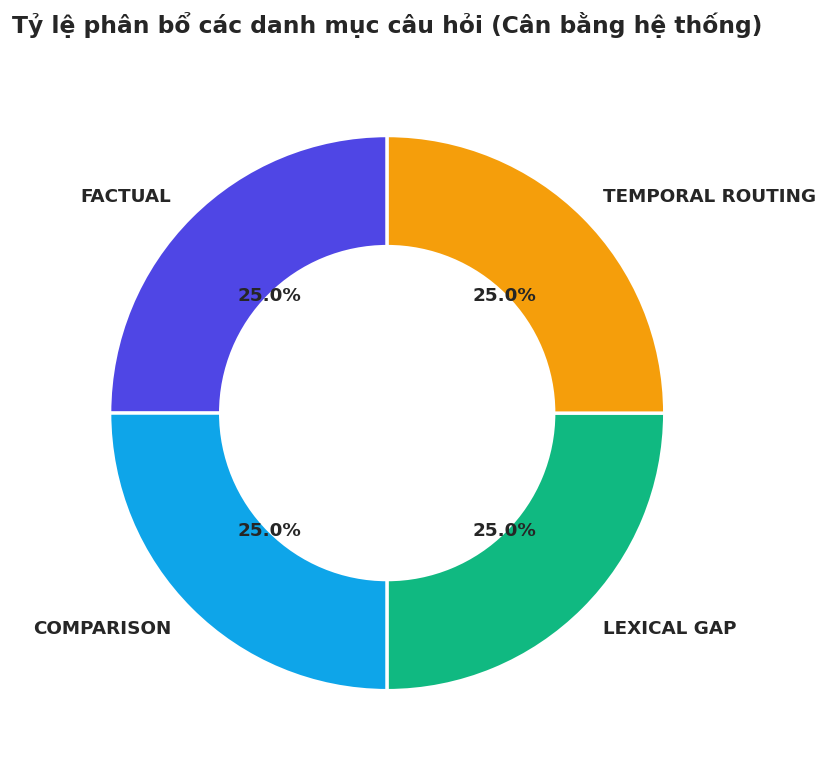

In [17]:
# 4. BIỂU ĐỒ 1: PHÂN BỐ DANH MỤC CÂU HỎI (Pie Chart / Donut Chart)
category_counts = df["category"].value_counts()
colors = ["#4f46e5", "#0ea5e9", "#10b981", "#f59e0b"]

plt.figure(figsize=(7, 7))
plt.pie(category_counts, labels=[c.upper().replace("_", " ") for c in category_counts.index], 
        autopct='%1.1f%%', startangle=90, colors=colors, 
        wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2), 
        textprops={'fontsize': 11, 'weight': 'bold'})

plt.title("Tỷ lệ phân bổ các danh mục câu hỏi (Cân bằng hệ thống)", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig("../../eval/figures/eda_category_distribution.png", dpi=150)
plt.show()

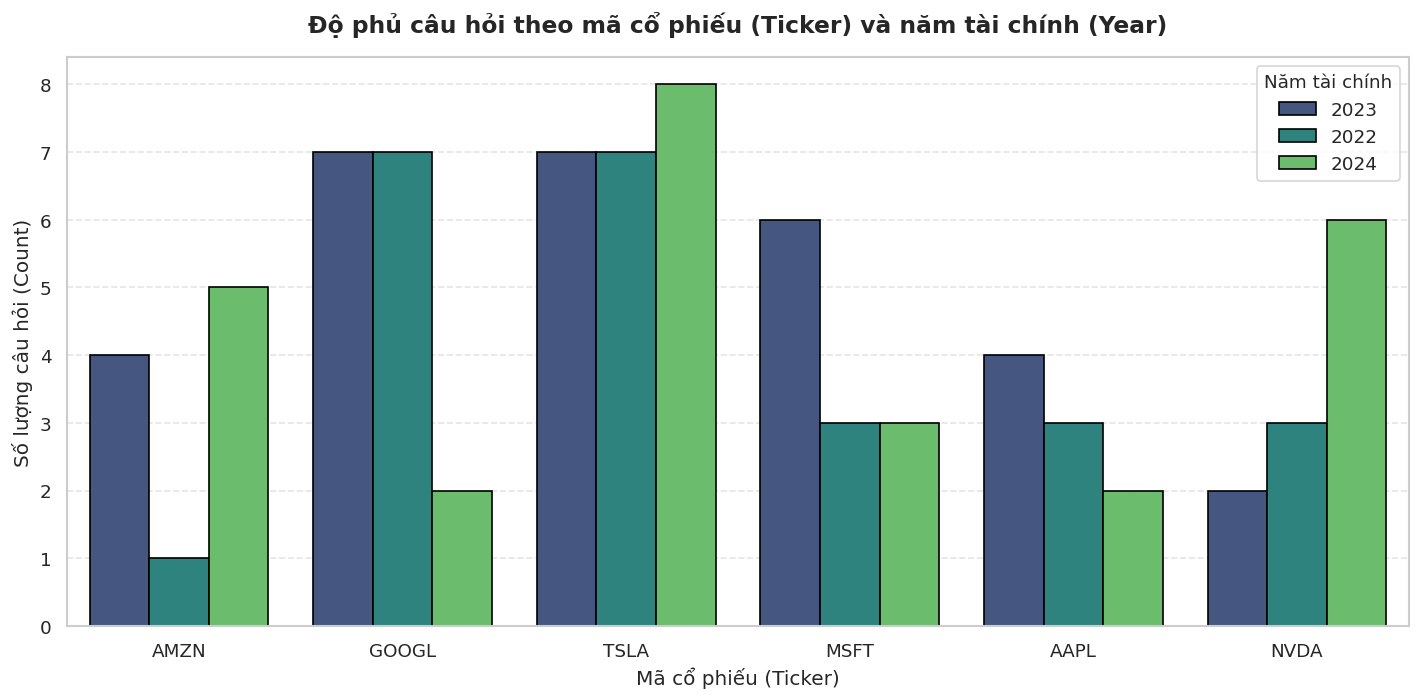

In [18]:
# 5. BIỂU ĐỒ 2: ĐỘ PHỦ THEO DOANH NGHIỆP & NĂM TÀI CHÍNH (Grouped Bar Chart)
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x="Ticker", hue="Year", palette="viridis", edgecolor="black")

plt.title("Độ phủ câu hỏi theo mã cổ phiếu (Ticker) và năm tài chính (Year)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Mã cổ phiếu (Ticker)", fontsize=12)
plt.ylabel("Số lượng câu hỏi (Count)", fontsize=12)
plt.legend(title="Năm tài chính", fontsize=11, title_fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("../../eval/figures/eda_ticker_year_coverage.png", dpi=150)
plt.show()

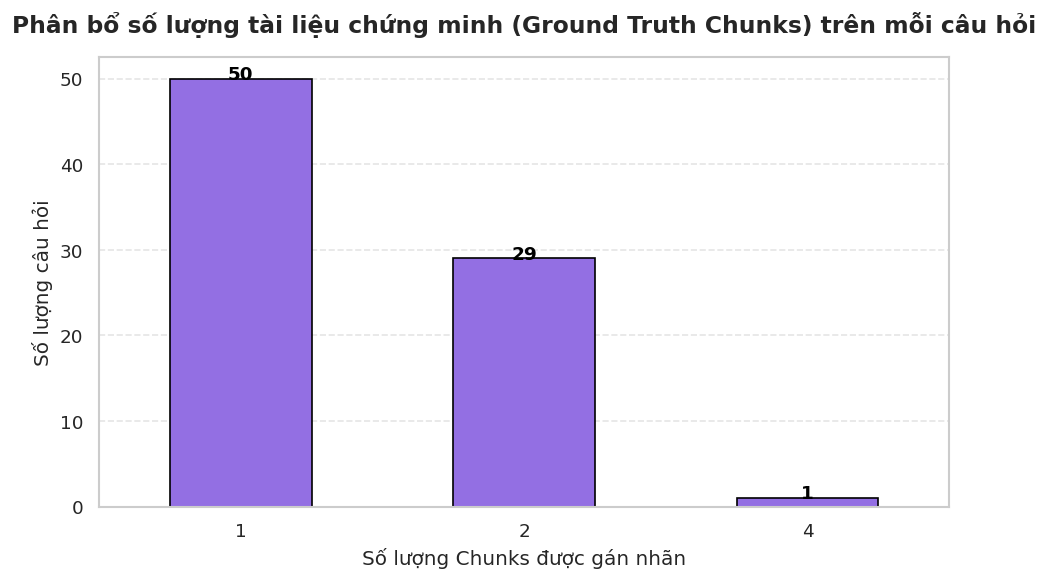

In [19]:
# 6. BIỂU ĐỒ 3: THỐNG KÊ SỐ LƯỢNG GROUND TRUTH CHUNKS TRÊN MỖI CÂU HỎI (Count Plot)
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x="GT_Count", color="#8b5cf6", edgecolor="black", width=0.5)

plt.title("Phân bổ số lượng tài liệu chứng minh (Ground Truth Chunks) trên mỗi câu hỏi", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Số lượng Chunks được gán nhãn", fontsize=12)
plt.ylabel("Số lượng câu hỏi", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height() + 0.5), 
                ha='center', va='center', fontsize=11, fontweight='bold', color='black')

plt.tight_layout()
plt.savefig("../../eval/figures/eda_gt_chunks_distribution.png", dpi=150)
plt.show()

C:\Users\huynh\AppData\Local\Temp\ipykernel_22020\600976783.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="category", y="Query_Length", palette="Set2", inner="quartile")


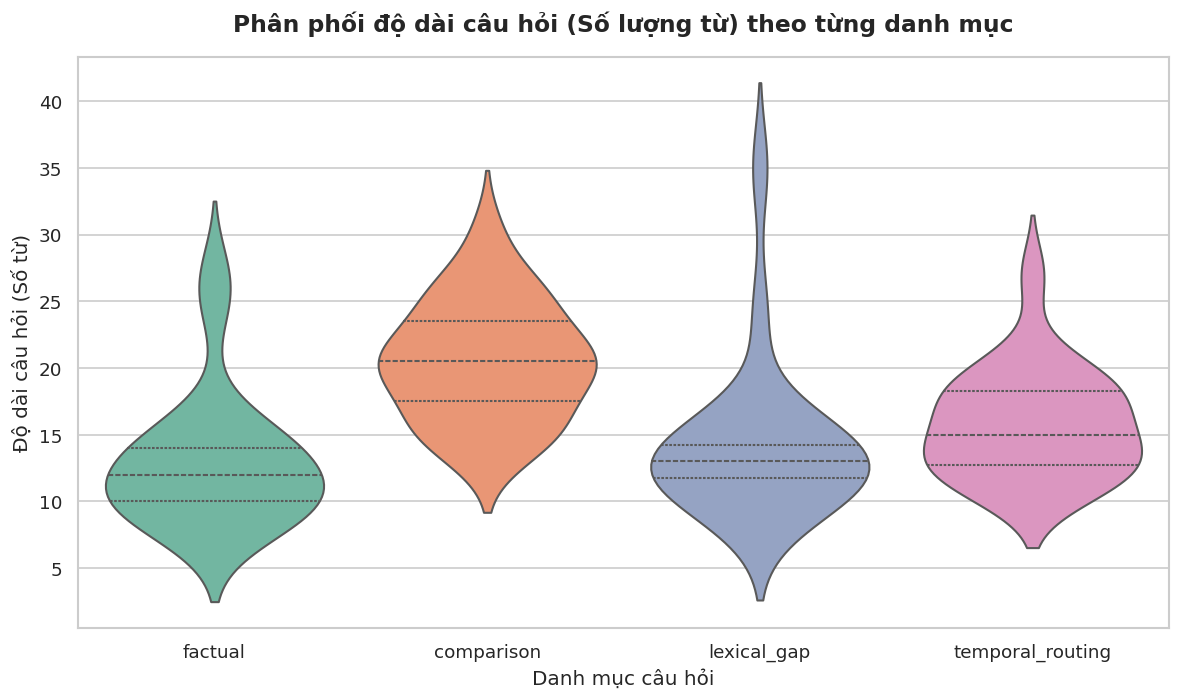

In [21]:
# 7. BIỂU ĐỒ 4: ĐỘ DÀI CÂU HỎI THEO TỪNG DANH MỤC (Violin Plot)
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x="category", y="Query_Length", palette="Set2", inner="quartile")

plt.title("Phân phối độ dài câu hỏi (Số lượng từ) theo từng danh mục", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Danh mục câu hỏi", fontsize=12)
plt.ylabel("Độ dài câu hỏi (Số từ)", fontsize=12)
plt.xticks(fontsize=11)
plt.tight_layout()
plt.savefig("../../eval/figures/eda_query_length_distribution.png", dpi=150)
plt.show()

---
## 8. PHÂN TÍCH CHẤT LƯỢNG GIẢI THÍCH NHÃN (GROUND TRUTH EXPLANATIONS)

Sự cải tiến vượt trội của bộ Ground Truth mới là sự xuất hiện của trường dữ liệu giải thích lí do gán nhãn `ground_truth_explanation` từ Trọng tài Llama-3.3-70B. Điều này cung cấp sự minh bạch tối đa cho dữ liệu:

* **Tránh rò rỉ dữ liệu:** Đảm bảo các đoạn văn bản được gán nhãn thực sự có giá trị toán học hoặc thông tin tài chính để suy diễn ra câu trả lời, thay vì chỉ chứa từ khóa tương đồng bề nổi.
* **Hỗ trợ vấn đáp:** Khi cô giáo kiểm tra bất kỳ câu hỏi nào trong 80 câu, sinh viên có thể truy xuất trực tiếp lời giải thích và con số thực tế được trích xuất từ báo cáo 10-K gốc để trình bày trước hội đồng.